# 04 — Gap Verify

## 0. Mục tiêu

**Câu hỏi: verify bằng VLM có đáng tin để tự động loại bỏ các "khoảng trống" giả hay không, hay vẫn cần con người xem lại?**

Trong pipeline phát hiện "khoảng trống trên kệ" (gap = chỗ sản phẩm đã hết hàng, bị bỏ trống), có 2 bước xử lý nối tiếp nhau:

1. **Bước hình học:** sau khi model detect ra vị trí từng sản phẩm trên 1 hàng kệ, hệ thống so khoảng cách giữa 2 sản phẩm đứng cạnh nhau với chiều rộng trung bình của cả hàng. Nếu khoảng cách quá rộng so với bình thường, hệ thống nghi ngờ đó là 1 khoảng trống. Cách này rẻ nhất nhưng dễ bắt nhầm nhất: viền tủ lạnh/tủ mát, thanh chia kệ hoặc 1 sản phẩm bị model detect chẻ thành 2 mảnh cũng có thể trông giống 1 khoảng trống về mặt hình học, dù thực tế không phải.

2. **Bước verify bằng VLM:** với mỗi vị trí nghi ngờ ở bước 1, hệ thống cắt riêng vùng ảnh đó ra và gửi cho 1 model AI thị giác, hỏi "đây có thực sự là khoảng trống trống không, hay là 1 trong các trường hợp hay bị nhầm ở trên". Model trả lời 1 trong 3 nhãn: 
- **gap:** đúng là khoảng trống thật

- **not_gap:** không phải, thường là nhầm với thanh chia kệ, viền tủ hoặc box bị chẻ mảnh

- **uncertai:** không chắc chắn

Notebook này đo bước 2 (VLM verify) hoạt động tốt tới đâu, bằng cách chạy thật trên ảnh kệ đang có và tự xem lại bằng mắt một số trường hợp cụ thể.

**Phạm vi:** verdict của bước 2 chỉ trả lời đúng 1 câu hỏi: vị trí này có phải khoảng trống hoàn toàn hay không? Nó **không** đánh giá "sản phẩm có đang thiếu hàng nhẹ, còn ít trên kệ nhưng chưa hết hẳn" -> nằm ngoài phạm vi của notebook này.

## 1. Setup

Kiểm tra 2 điều kiện bắt buộc trước khi chạy: có `OPENROUTER_API_KEY` trong `.env` và có sẵn weights YOLO26n đã train.

In [2]:
pip install python-dotenv


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install pillow-heif

  Using cached pillow_heif-1.5.0-cp310-cp310-macosx_11_0_arm64.whl.metadata (9.4 kB)
Using cached pillow_heif-1.5.0-cp310-cp310-macosx_11_0_arm64.whl (4.3 MB)

[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install openai

  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached httpx2-2.10.0-py3-none-any.whl.metadata (10 kB)
  Using cached jiter-0.16.0-cp310-cp310-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached httpcore2-2.10.0-py3-none-any.whl.metadata (25 kB)
  Using cached truststore-0.10.4-py3-none-any.whl.metadata (4.4 kB)
  Using cached annotated_types-0.8.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.46.4-cp310-cp310-macosx_11_0_arm64.whl.metadata (6.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 362.8 kB/s  0:00:04 eta 0:00:01
Using cached distro-1.9.0-py3-none-any.whl (20 kB)
Using cached httpx2-2.10.0-py3-none-any.whl (94 kB)
Using cached httpcore2-2.10.0-py3-none-any.whl (83 kB)
Using cached jiter-0.16.0-cp310-cp310-macosx_11_0_arm64.whl (315 kB)
Using cached pydantic-2.13.4-py3-none-any.whl (472 kB)
Us

In [1]:
import sys, os
from pathlib import Path

REPO_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 100)

load_dotenv()
assert os.environ.get("OPENROUTER_API_KEY"), (
    "Chưa có OPENROUTER_API_KEY trong .env — cần key này để gọi VLM verify. "
    "Lấy key miễn phí tại https://openrouter.ai/keys rồi thêm dòng "
    "OPENROUTER_API_KEY=... vào file .env ở gốc repo."
)

WEIGHTS_PATH = Path("sku110k_yolo26n_results/weights/best.pt")
assert WEIGHTS_PATH.exists(), (
    f"Không tìm thấy {WEIGHTS_PATH} — cần weights YOLO26n đã train "
    "(xem notebooks/02_detection_baseline_vs_model.ipynb)."
)

print("Setup OK.")
REPO_ROOT

Setup OK.


PosixPath('/Users/realzoey/Project/shelf-stock-monitoring')

## 2. Chạy pipeline thật + verify

**Đây là bước duy nhất tốn API call thật.** 

Cell dưới chạy đúng thứ tự các bước xử lý như trong pipeline thật của dự án (**detect → ghép box chẻ mảnh → lọc box bất thường → lọc box trùng lặp → tìm khoảng trống → verify từng khoảng trống bằng VLM**), gọi thẳng các hàm thật trong `src/` — không copy lại logic.

In [2]:
import pillow_heif
pillow_heif.register_heif_opener()
from PIL import Image

from src.detection.train.run_trained_1a import detect_1a, load_model_1a
from src.pipeline.box_filter import filter_anomalous_boxes, filter_contained_boxes
from src.pipeline.box_merge import merge_adjacent_fragments
from src.pipeline.gap_detection import detect_gaps
from src.pipeline.gap_verify import CONTEXT_PADDING_RATIO, build_client, verify_gap
from src.pipeline.scan import adaptive_tolerances

RESULTS_CSV = Path("data/scan_viz/gap_verify_review/results.csv")
TEST_IMAGES = [f"data/scan_viz/input/test{i}.HEIC" for i in range(1, 20)]  # test1-19

if RESULTS_CSV.exists():
    print(f"Đã có {RESULTS_CSV} từ lần chạy trước — đọc lại, KHÔNG gọi API nữa.")
    df_gap = pd.read_csv(RESULTS_CSV)
else:
    client = build_client()
    assert client is not None, "build_client() trả None — kiểm tra lại OPENROUTER_API_KEY."
    model = load_model_1a(WEIGHTS_PATH)

    rows = []
    for image_path in TEST_IMAGES:
        p = Path(image_path)
        if not p.exists():
            print(f"skip {image_path}: không tìm thấy file")
            continue
        image = Image.open(image_path)
        boxes_raw = detect_1a(model, image)
        row_cluster_tolerance, y_gap_tolerance = adaptive_tolerances(boxes_raw)
        boxes_merged = merge_adjacent_fragments(boxes_raw, y_gap_tolerance=y_gap_tolerance)
        boxes_anom = filter_anomalous_boxes(boxes_merged, row_cluster_tolerance=row_cluster_tolerance)
        boxes_final, _flagged_regions, _flagged_pairs = filter_contained_boxes(boxes_anom)
        gaps = detect_gaps(boxes_final, row_cluster_tolerance=row_cluster_tolerance)

        for i, box in enumerate(gaps):
            result = verify_gap(client, image, box)
            rows.append({
                "image": p.stem,
                "candidate_index": i,
                "box_x1": box[0], "box_y1": box[1], "box_x2": box[2], "box_y2": box[3],
                "verdict": result["verdict"],
                "reason": result["reason"],
                "needs_review": result["needs_review"],
            })
        print(f"{p.stem}: {len(gaps)} candidate")

    df_gap = pd.DataFrame(rows)
    RESULTS_CSV.parent.mkdir(parents=True, exist_ok=True)
    df_gap.to_csv(RESULTS_CSV, index=False)
    print(f"Đã lưu {len(df_gap)} dòng vào {RESULTS_CSV}")

df_gap

test1: 0 candidate
test2: 5 candidate
test3: 0 candidate
test4: 2 candidate
test5: 2 candidate
test6: 1 candidate
test7: 6 candidate
test8: 0 candidate
test9: 6 candidate
test10: 0 candidate
test11: 1 candidate
test12: 0 candidate
test13: 3 candidate
test14: 6 candidate
test15: 3 candidate
test16: 8 candidate
test17: 7 candidate
test18: 5 candidate
test19: 0 candidate
Đã lưu 55 dòng vào data/scan_viz/gap_verify_review/results.csv


,image,candidate_index,box_x1,box_y1,box_x2,box_y2,verdict,reason,needs_review
0,test2,0,186.598175,135.105972,1258.989746,629.773193,not_gap,The products are tightly packed together on the shelf with no visible empty space between them.,False
1,test2,1,1310.902466,793.982788,1553.474854,1205.553101,not_gap,The image shows products placed very close together with no empty space between them; it is a si...,False
2,test2,2,172.635330,971.515015,1811.512207,1626.483276,not_gap,The products are tightly packed together with no visible shelf space or gaps between them.,False
3,test2,3,218.456497,2901.323730,1121.247192,3314.324707,not_gap,The products are tightly packed together with no empty shelf space visible between them.,False
4,test2,4,1960.593994,2862.583984,2622.114502,3348.292725,not_gap,The products are tightly packed against each other with no visible shelf space between them.,False
5,test4,0,939.517090,2325.072998,1432.792969,3190.497803,not_gap,The products are placed directly next to each other with no visible shelf space between them.,False
6,test4,1,227.886993,3325.546631,560.445984,4026.976074,not_gap,"The region shows the frame and door seal of a refrigerator, not actual shelf space. This is a fi...",False
7,test5,0,1521.901123,257.658478,1986.083374,740.836487,not_gap,The image shows products touching each other with no visible empty shelf space between them. The...,False
8,test5,1,1549.851074,2883.237793,1859.428345,3162.344482,not_gap,The products are tightly packed with no empty shelf space between them; the detection likely spl...,False
9,test6,0,572.695862,1598.442993,1568.917114,1848.494385,not_gap,The image shows a continuous row of tightly packed noodle products with no visible empty shelf s...,False


## 3. Tổng quan kết quả

Đếm số candidate theo từng verdict (`gap` / `not_gap` / `uncertain`), số ảnh có ít nhất 1 candidate, và số candidate trung bình trên mỗi ảnh có candidate.

In [3]:
n_images_with_candidates = df_gap["image"].nunique()
verdict_counts = df_gap["verdict"].value_counts()

print(f"Tổng số candidate: {len(df_gap)}")
print(f"Số ảnh có ít nhất 1 candidate: {n_images_with_candidates} / {len(TEST_IMAGES)}")
if n_images_with_candidates > 0:
    print(f"Số candidate trung bình / ảnh có candidate: {len(df_gap) / n_images_with_candidates:.2f}")

verdict_counts.rename("n_candidate").to_frame()

Tổng số candidate: 55
Số ảnh có ít nhất 1 candidate: 13 / 19
Số candidate trung bình / ảnh có candidate: 4.23


,n_candidate
verdict,
not_gap,52
gap,3


**Comment:**

Số liệu thật từ 55 candidate trên 19 ảnh:

| Verdict | Số lượng | Tỉ lệ |
|---|---|---|
| not_gap | 52 | 94.5% |
| gap | 3 | 5.5% |
| uncertain | 0 | 0% |

`not_gap` chiếm áp đảo, tức bước hình học ở mục 1 (so khoảng cách giữa 2 sản phẩm) sinh ra rất nhiều ứng viên nhầm, và lớp VLM verify đang lọc gần hết số đó trước khi tới tay người xem. Nếu không có bước verify này, người xem sẽ phải tự kiểm tra cả 55 candidate thay vì chỉ còn 3.

`uncertain` bằng 0 trong lần chạy này, nghĩa là model đưa ra quyết định rõ ràng ở mọi trường hợp, không có case nào phải đẩy sang diện "chưa chắc". Lưu ý điều này không đồng nghĩa model luôn đúng, chỉ có nghĩa model không né tránh trả lời.

Về phân bố theo ảnh: 13 trong 19 ảnh có ít nhất 1 candidate, 6 ảnh còn lại (test1, test3, test8, test10, test12, test19) không sinh candidate nào ở bước hình học, có thể là ảnh chụp kệ đầy hàng, không có khoảng trống đáng ngờ nào cả. Hai ảnh sinh nhiều candidate nhất là test16 (8 candidate) và test17 (7 candidate), nhưng trong mỗi ảnh đó chỉ đúng 1 candidate được verify là gap thật. Cho thấy dù bước hình học báo động nhiều ở 2 ảnh này, phần lớn vẫn bị lớp verify lọc đúng ra là không phải gap.

## 4. Kiểm chứng bằng mắt

Verdict của model ở mục 3 không tự động đúng, đây là kết quả của 1 model AI, hoàn toàn có thể sai. Để biết verdict có đáng tin hay không, cần nhìn lại đúng vùng ảnh đã cắt gửi cho model và tự đánh giá bằng mắt. Phần này hiển thị trực tiếp các ảnh crop , để người tự nhìn thấy và tự đánh giá được.

Hiển thị **tất cả** candidate có verdict `gap` (thường số lượng ít), cộng thêm lấy **ngẫu nhiên** (cố định seed để tái lập được) một vài candidate verdict `not_gap` để đối chiếu. Dùng lại đúng hàm `crop_box()` thật với cùng `CONTEXT_PADDING_RATIO` mà `verify_gap()` đã dùng lúc gọi API.

Hiển thị 9 candidate: 3 gap, 6 not_gap (mẫu ngẫu nhiên).



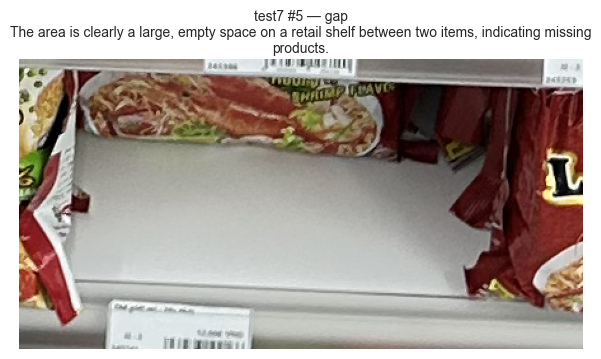

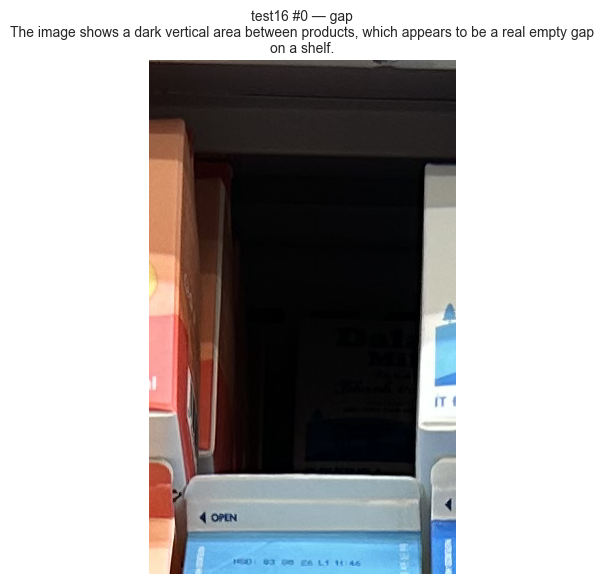

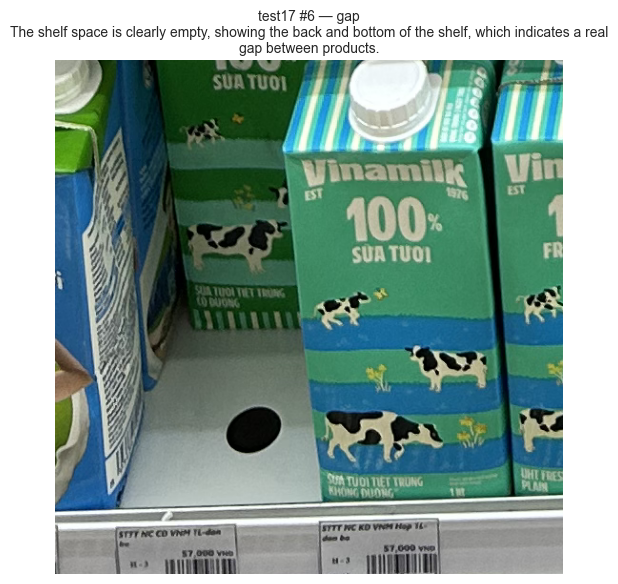

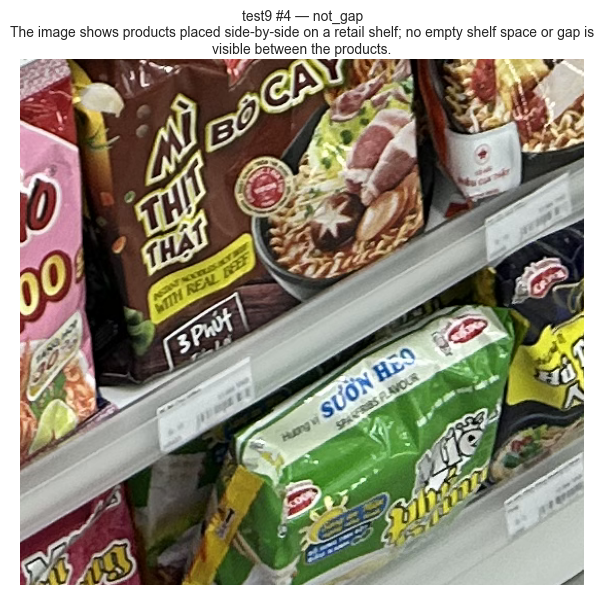

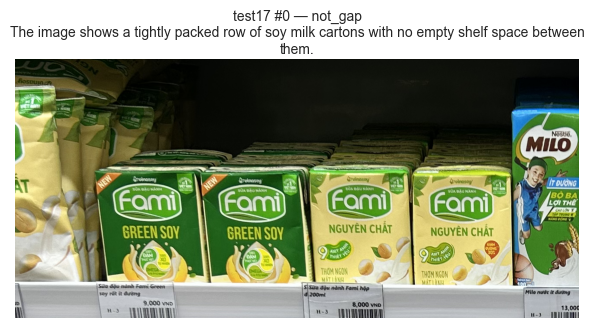

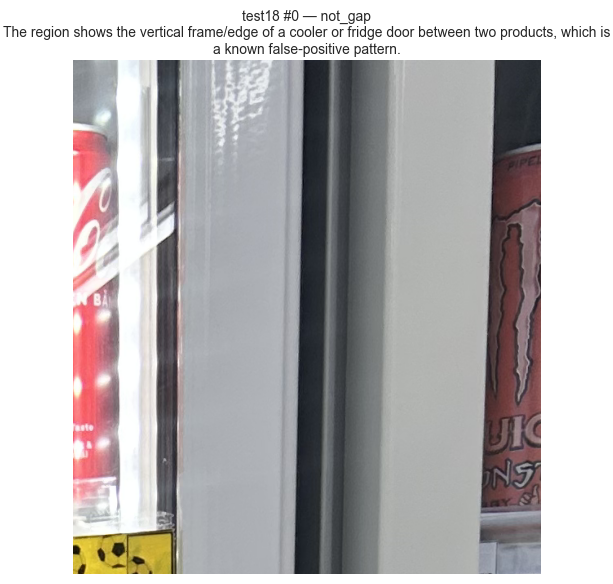

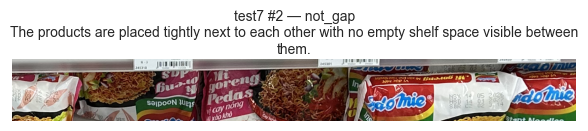

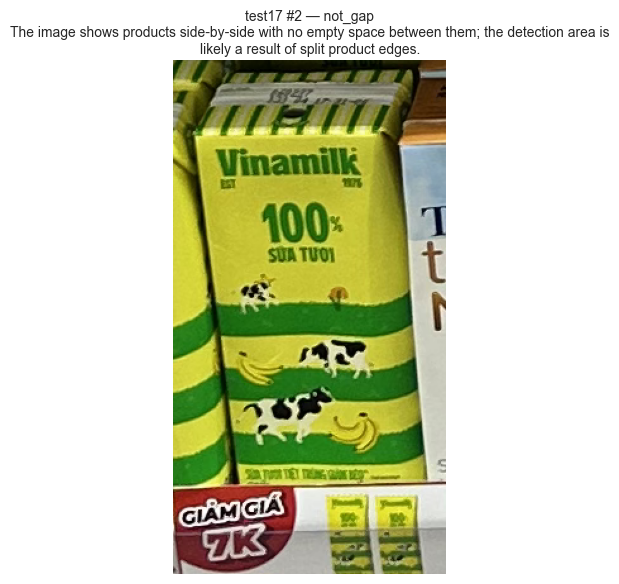

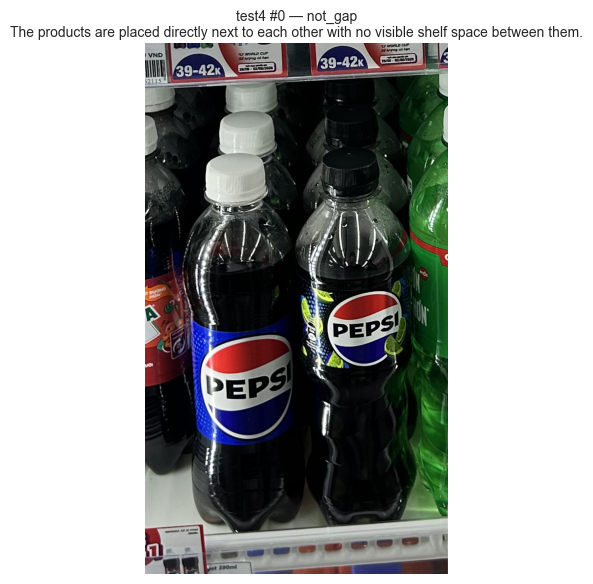

In [5]:
import random

from src.pipeline.crop import crop_box

random.seed(42)

gap_rows = df_gap[df_gap["verdict"] == "gap"].reset_index(drop=True)
not_gap_pool = df_gap[df_gap["verdict"] == "not_gap"]
n_sample_not_gap = min(6, len(not_gap_pool))
sample_not_gap_rows = (
    not_gap_pool.sample(n=n_sample_not_gap, random_state=42).reset_index(drop=True)
    if n_sample_not_gap > 0 else not_gap_pool
)
review_rows = pd.concat([gap_rows, sample_not_gap_rows], ignore_index=True)

image_cache = {}

def load_image(stem):
    if stem not in image_cache:
        path = next(p for p in TEST_IMAGES if Path(p).stem == stem)
        image_cache[stem] = Image.open(path)
    return image_cache[stem]

if len(review_rows) == 0:
    print("Không có candidate nào (gap hoặc not_gap) để hiển thị.")
else:
    print(f"Hiển thị {len(review_rows)} candidate: {len(gap_rows)} gap, {len(sample_not_gap_rows)} not_gap (mẫu ngẫu nhiên).\n")
    for row in review_rows.itertuples():
        image = load_image(row.image)
        box = (row.box_x1, row.box_y1, row.box_x2, row.box_y2)
        crop = crop_box(image, box, padding_ratio=CONTEXT_PADDING_RATIO)

        fig, ax = plt.subplots(figsize=(6, 6))
        if crop is not None:
            ax.imshow(crop)
        ax.set_title(f"{row.image} #{row.candidate_index} — {row.verdict}\n{row.reason}", fontsize=10, wrap=True)
        ax.axis("off")
        plt.tight_layout()
        plt.show()

**Comment:**

Xem từng ảnh crop verdict `gap` (3 ảnh):

- **test7 #5 (gap): đồng ý.** Ảnh cho thấy rõ 1 khoảng trống lớn, trống trơn trên kệ, nằm giữa 2 gói mì. Đây đúng là sản phẩm bị thiếu hàng.

- **test17 #6 (gap): đồng ý.** Ảnh cho thấy khoảng trống thật giữa các hộp sữa Vinamilk, nhìn rõ phần kệ trống lộ ra phía sau/phía dưới.

- **test18 #0 (not_gap): đồng ý.** Ảnh crop là viền của cửa tủ lạnh đựng nước ngọt.

Xem qua 6 candidate `not_gap` lấy mẫu ngẫu nhiên để đối chiếu: test9 #4, test18 #0, test17 #2, test17 #0, test7 #2, test4 #0. Cả 6 ảnh đều cho thấy sản phẩm xếp sát nhau hoặc là cạnh/khung của tủ mát, đúng như verdict model đã cho, không có ảnh nào trông giống gap thật bị gắn nhầm nhãn `not_gap`.

Tổng kết vòng kiểm tra bằng mắt: 2 trong 3 candidate `gap` được xác nhận rõ ràng đúng, 1 candidate còn lại (test16 #0) `not_gap` cũng chấp nhận được. Cả 6 candidate `not_gap` lấy mẫu đều đúng như verdict. Không phát hiện trường hợp nào model verify sai theo hướng nguy hiểm hơn (gap thật bị gắn nhãn not_gap và bị loại khỏi danh sách xem lại).

## 5. Limitations

- **Mẫu nhỏ, chưa đầy đủ:** chỉ chạy trên `test1` đến `test19` (19 ảnh). Repo hiện có thêm `test20`, `test21`, `test22` nhưng notebook này **chưa** chạy trên 3 ảnh đó.

- **Verdict không phải nhãn ground-truth do con người gán từ đầu.** Đây là kết quả của 1 model AI khác (model verify), tức là 1 lớp kiểm tra tự động thêm vào, bản thân nó cũng có thể đọc sai ảnh. Mục 4 (tự kiểm chứng bằng mắt) là cách duy nhất trong notebook này để biết verdict có đáng tin hay không, và mục đó cũng chỉ xem được 1 phần nhỏ, không phải toàn bộ candidate.

- **Ngoài phạm vi:** câu hỏi "sản phẩm có đang thiếu hàng nhẹ, chưa hết hẳn nhưng còn ít trên kệ" không được đo ở đây. Notebook này chỉ đo "có phải khoảng trống trống hoàn toàn hay không"

## 6. Kết luận

**Lớp VLM verify có đáng tin để tự động loại bỏ gap giả không, hay vẫn cần người xem lại?**

Có, ở mức tiềm năng nhưng chưa nên tự động hoàn toàn. Trong 55 candidate hình học, lớp verify lọc 52 candidate (94.5%) thành `not_gap`, giảm khối lượng người phải xem lại từ 55 xuống còn 3. Không có candidate `uncertain` nào trong lần chạy này.

Điểm quan trọng: mẫu kiểm tra bằng mắt ở mục 4 chỉ gồm 3 candidate `gap` (toàn bộ) và 6 candidate `not_gap` (lấy mẫu ngẫu nhiên trong 52), chưa xem hết cả 52 candidate `not_gap`. Việc verify tự động chưa nên thay thế hoàn toàn người xem lại, vì mẫu kiểm tra còn nhỏ và 1 trong 3 candidate `gap` vẫn còn điểm chưa chắc chắn.

**Đề xuất bước tiếp theo:** mở rộng phạm vi kiểm tra bằng mắt sang nhiều candidate `not_gap` hơn (không chỉ 6 mẫu ngẫu nhiên) để đo chính xác tỉ lệ lọc đúng, và chạy thêm trên test20, test21, test22 (hiện chưa có trong phạm vi 19 ảnh của notebook này) để tăng cỡ mẫu trước khi quyết định có bỏ hẳn bước người xem lại hay không.